In [ ]:
# SPDX-License-Identifier: CC-BY-4.0
# Code for "Active Continual Learning with Metaplastic Binary Bayesian Neural Networks"
# Kellian Cottart, Théo Ballet, Djohan Bonnet, Damien Querlioz
# Portions of the code are adapted from the Pytorch project (BSD-3-Clause)
# Author: Kellian Cottart <kellian.cottart@gmail.com>
# Date: 2025-30-01

In [ ]:

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import os
import seaborn as sns
import re
import json
import pandas as pd
AXESSIZE = 28
FONTSIZE = 26
TICKSIZE = 24   
LEGENDSIZE = 26
plt.rcParams['svg.fonttype'] = 'none'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.05"
results_folder = "results-appendix-openloris-al-variation-ratio"
figures_folder = "fig-appendix-openloris-al-variation-ratio"
os.makedirs(figures_folder, exist_ok=True)
df = pd.DataFrame()
# iterate through all root folders in the results folder
for folder in os.listdir(results_folder):
    current_path = os.path.join(results_folder, folder)
    # extract the name from the first config
    config_path = os.path.join(current_path, "config0/config.json")
    with open(config_path, "r") as f:
        config = json.load(f)
    # n_iterations is the number of config folders
    n_iterations = len([f for f in os.listdir(current_path) if f.startswith("config") and os.path.isdir(os.path.join(current_path, f))])
    
    # Add the row of parameters to the dataframe   
    def method_wrapper(config):
        if "active_learning" in config["network_params"]:
            if not "mode" in config["network_params"]["active_learning"]:
                return list(config["network_params"]["active_learning"].keys())[0]  
            else:
                mode_map = {
                    0: "Epistemic",
                    1: "Aleatoric",
                    2: "Predictive",
                    3: "Variation ratio",
                    4: "Random",
                    5: "Var. w/ labels"
                }
                return mode_map.get(config["network_params"]["active_learning"]["mode"], "Random")
        return "Random"
    
    # Add the row of parameters to the dataframe   
    field = [key for key in config.keys() if "ewc" in key]
    row = {
        "path": current_path,
        "opt": config["optimizer"],
        "n_tasks": config["n_tasks"],
        "n_epochs": config["epochs"],
        "n_train_samples": config["n_train_samples"] if "n_train_samples" in config else 1,
        "n_test_samples": config["n_test_samples"] if "n_test_samples" in config else 1,
        "n_iterations": n_iterations,
        "batch_size": config["train_batch_size"],
        # key containing ewc but not strictly equal to ewc
        "ewc": config[field[0]] if len(field) > 0 else "none",
        "method": method_wrapper(config),
        "n_active_learning_samples": int(config["network_params"]["active_learning"]["samples"]) if "active_learning" in config["network_params"] and "samples" in config["network_params"]["active_learning"] else 0,
        "threshold": float(config["network_params"]["active_learning"]["threshold"]) if "active_learning" in config["network_params"] and "threshold" in config["network_params"]["active_learning"] else 0.0,
        "N": int(config["optimizer_params"]["N"]) if "N" in config["optimizer_params"] else "none",
        "interleaved": int(config["task_params"].get("interleaved", 0)),
        "n_splits_per_epoch": int(config.get("n_splits_per_epoch", 1)),
    }
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)

In [173]:
data = []
for idx, row in df.iterrows():
    path = row["path"]
    n_tasks = row["n_tasks"]
    n_epochs = row["n_epochs"]
    n_iterations = row["n_iterations"]
    n_splits_per_epoch = row["n_splits_per_epoch"] if "n_splits_per_epoch" in row else 1
    full_accuracies = []
    full_updates = []
    final_updates = []
    full_wras = []
    full_uras = []
    
    for it in range(n_iterations):
        current_it_path = os.path.join(path, f"config{it}")
        accuracy_path = os.path.join(current_it_path, "accuracy")
        uncertainty_path = os.path.join(current_it_path, "uncertainty")
        accuracies = []
        updates = []
        wras = []
        uras = []
        for task in range(n_tasks):
            for epoch in range(n_epochs):
                for split in range(n_splits_per_epoch):
                    suffix = f"split={split}-task={task}-epoch={epoch}.npy"
                    accuracies.append(jnp.load(os.path.join(accuracy_path, suffix)))
                    updates.append(jnp.load(os.path.join(accuracy_path, "iterations-"+suffix)))
                    wras.append(jnp.load(os.path.join(accuracy_path, "wra-"+suffix)))
                    uras.append(jnp.load(os.path.join(accuracy_path, "ura-"+suffix)))
        full_accuracies.append(np.array(accuracies))
        final_updates.append(jnp.load(os.path.join(current_it_path, "iterations.npy")))
        full_updates.append(np.array(updates))
        full_wras.append(np.array(wras))
        full_uras.append(np.array(uras))

    full_accuracies = np.array(full_accuracies)*100
    full_wras = np.array(full_wras)*100
    full_uras = np.array(full_uras)*100
    full_updates = np.array(full_updates)
    
    final_updates_mean = np.array(final_updates).mean()
    final_updates_std = np.array(final_updates).std()
    accuracy_array_mean = np.mean(full_accuracies, 0)[-1, :].mean()
    accuracy_array_std = np.mean(full_accuracies[:, -1, :], -1).std()
    data.append((accuracy_array_mean, accuracy_array_std, full_updates, full_accuracies, final_updates_mean, final_updates_std, full_wras, full_uras))

# Add new columns to df
df["accuracies_mean"] = [d[0] for d in data]
df["accuracies_std"] = [d[1] for d in data]
df["updates"] = [d[2] for d in data]
df["accuracies"] = [d[3] for d in data]
df["final_updates"] = [d[4] for d in data]
df["final_updates_std"] = [d[5] for d in data]
df["wras"] = [d[6] for d in data]
df["uras"] = [d[7] for d in data]


In [176]:
# make a subdf with only final updates and accuracies
subdf = df[df["method"] == "Variation ratio"]
# compute percentage
max_ex = df["final_updates"].max()
# print max accuracy for random
random_df = df[df["method"] == "Random"]
max_random_accuracy = random_df["accuracies_mean"].max()
print(f"Max random accuracy: {max_random_accuracy:.2f}%")

# add random df to subdf
subdf = pd.concat([subdf, random_df], ignore_index=True)

# scale final_updates to percentage of max_ex for variation-ratio rows
subdf["final_updates"] = np.array(subdf["final_updates"]) / max_ex * 100
subdf["final_updates_std"] = np.array(subdf["final_updates_std"]) / max_ex * 100
subdf = subdf[["method", "final_updates", "final_updates_std", "accuracies_mean", "accuracies_std", "n_active_learning_samples", "threshold"]]
subdf = subdf.sort_values("final_updates")
print(subdf.to_latex(index=False, float_format="%.2f"))



Max random accuracy: 87.76%
\begin{tabular}{lrrrrrr}
\toprule
         method &  final\_updates &  final\_updates\_std &  accuracies\_mean &  accuracies\_std &  n\_active\_learning\_samples &  threshold \\
\midrule
Variation ratio &           0.00 &               0.00 &             5.26 &            0.00 &                         10 &       0.90 \\
Variation ratio &           0.00 &               0.00 &             5.26 &            0.00 &                         25 &       0.80 \\
Variation ratio &           0.00 &               0.00 &             5.26 &            0.00 &                         25 &       0.84 \\
Variation ratio &           0.00 &               0.00 &             5.26 &            0.00 &                         25 &       0.88 \\
Variation ratio &           0.00 &               0.00 &             5.26 &            0.00 &                         25 &       0.76 \\
Variation ratio &           0.00 &               0.00 &             5.26 &            0.00 &             

/tmp/ipykernel_768608/3601044987.py:39: UserWarning: The markers list has more values (8) than needed (5), which may not be intended.
  sns.lineplot(


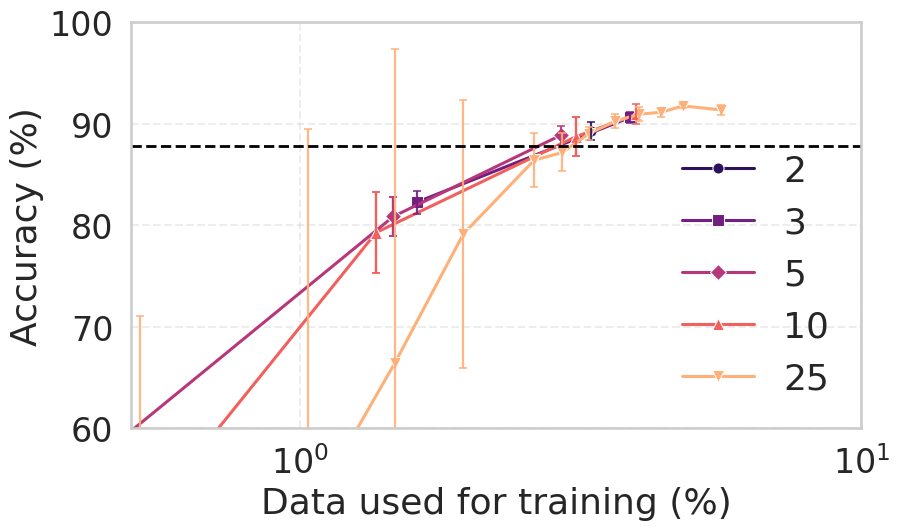

In [175]:
subdf = df[df["method"] == "Variation ratio"].copy()
subdf["final_updates_np"] = subdf["final_updates"].apply(np.asarray)
subdf["percentage"] = subdf["final_updates_np"].apply(
    lambda x: x / max_ex * 100
)
subdf["percentage"] = subdf["final_updates"] / max_ex * 100
# sort 
subdf = subdf.sort_values("n_active_learning_samples", ascending=False)

plot_df = subdf.melt(
    id_vars=["n_active_learning_samples", "percentage"],
    value_vars=["accuracies_mean"],
    var_name="metric",
    value_name="accuracy"
)

std_df = subdf.melt(
    id_vars=["n_active_learning_samples", "percentage"],
    value_vars=["accuracies_std"],
    var_name="metric",
    value_name="std"
)
# --- styling ---
sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.9
)

palette = dict(
    zip(
        sorted(subdf["n_active_learning_samples"].unique()),
        sns.color_palette("magma", n_colors=subdf["n_active_learning_samples"].nunique())
    )
)
markers = ["o", "s", "D", "^", "v", "P", "X", "*"]  # extend if needed

plt.figure(figsize=(9, 5.5))
sns.lineplot(
    data=plot_df,
    x="percentage",
    y="accuracy",
    hue="n_active_learning_samples",
    style="n_active_learning_samples",      # <-- marker varies with samples
    markers=markers,
    dashes=False,
    palette=palette,
    linewidth=2.2,
    markersize=8,
)

ax = plt.gca()

for k, color in palette.items():
    curve = subdf[subdf["n_active_learning_samples"] == k].sort_values("percentage")

    x = curve["percentage"].to_numpy()
    y = curve["accuracies_mean"].to_numpy()
    yerr = curve["accuracies_std"].to_numpy()

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="none",          # no extra markers
        ecolor=color,
        elinewidth=1.6,
        capsize=3,
        capthick=1.2,
        alpha=0.9,
        zorder=2
    )

# add horizontal line for random
plt.axhline(
    y=max_random_accuracy,
    color="black",
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Data used for training (%)", fontsize=FONTSIZE)
plt.ylabel("Accuracy (%)", fontsize=FONTSIZE)
plt.xscale("log")
plt.tick_params(axis='both', which='major', labelsize=TICKSIZE)
plt.xticks(fontsize=TICKSIZE)
plt.yticks(fontsize=TICKSIZE)
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(
    fontsize=LEGENDSIZE,
    frameon=False,
    loc="best"
)
plt.tight_layout()
plt.savefig(
    os.path.join(
        figures_folder,
        "openloris-unbalanced-variation-ratio-K-samples.svg"
    ),
    dpi=300
)
plt.ylim(60, 100)
plt.xlim(5e-1, 10)
plt.show()
